# Scrach file for Microtearing Mode Analysis

In [1]:
# %% Import JAX and enable 64-bit precision
import jax
jax.config.update("jax_enable_x64", True)

In [2]:
import numpy as np
import re
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib as mpl
from functools import partial
import importlib

import timeit
from tqdm.notebook import tqdm

import diffrax
import optimistix as optx

In [7]:
%load_ext autoreload
%autoreload 2

from c1lgkt.jax.fields.equilibrium import Equilibrium
from c1lgkt.jax.fields.geometry_handlers import GeometryHandler, FieldlinePusher, FieldlineArgs
from c1lgkt.jax.analysis.file_utils import load_gfile
from c1lgkt.jax.fields.geometry_handlers import f_fieldline_axial, cond_axial_crossing

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


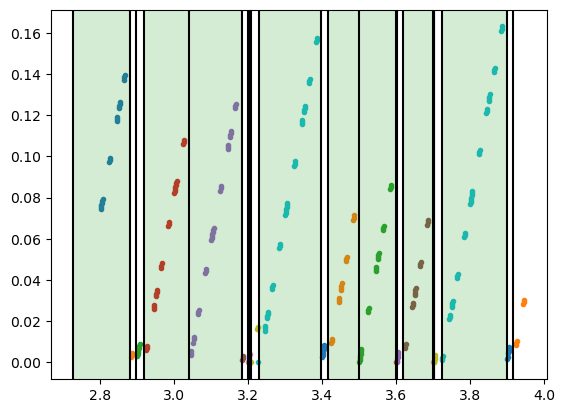

In [4]:
# %% Load TS data from files exported from OMFIT, then find the ELM times

rootdir = R'C:\Users\maple\OneDrive\Research\IFS\Scripts\gpr'

def load_datfile(filename):
    data = dict()

    with open(filename, 'r') as f:
        lines = f.readlines()
        ncol = len(lines[3].split())
        nrow = len(lines)-3

        col_labels = lines[1].split()
        col_units = lines[2].split()

        for c in range(ncol):
            data[col_labels[c]] = np.empty(nrow)

        for k in range(nrow):
            rowdata = list(map(float,lines[k+3].split()))
            for c in range(ncol):
                data[col_labels[c]][k] = rowdata[c]

    return data

data = load_datfile(Rf'{rootdir}\omfit_generated\ws_174864_3370.39.dat')


# Determine the unique values of Z_TS and time
xch, xbins, xcounts = np.unique(data['Z_TS'], return_inverse=True, return_counts=True)
tch, tbins, tcounts = np.unique(data['time'], return_inverse=True, return_counts=True)

# Get time since ELM corresponding to tch
time_since_elm = np.zeros(len(tch))
for k in range(len(tch)):
    time_since_elm[k] = np.average(data['since_ELM'][tbins==k])

# Determine the indices where the time since last ELM decreases
elm_indices = np.where(np.diff(time_since_elm) < np.diff(tch)*0.5)[0]

# Compute the times for the ELMs
t_elms = np.zeros(len(elm_indices)+1)
curr_index = 0
for k in range(len(elm_indices)+1):
    if k == len(elm_indices):
        next_index = -1
    else:
        next_index = elm_indices[k]+1

    t_elms[k] = np.average(tch[curr_index:next_index] - time_since_elm[curr_index:next_index])

    curr_index = next_index

# Determine which ELMs to include
elm_okay = np.diff(t_elms) > 0.05
#elm_whitelist = np.searchsorted(t_elms, [2.96, 3.12, 3.45, 3.56, 3.65]) - 1
#for k in range(len(elm_okay)):
#    if k in elm_whitelist:
#        elm_okay[k] = True
#    else:
#        elm_okay[k] = False

# Plot the ELM times
plt.figure()
curr_index = 0
for k in range(len(elm_indices)+1):
    if k == len(elm_indices):
        next_index = -1
    else:
        next_index = elm_indices[k]+1

    plt.scatter(tch[curr_index:next_index], time_since_elm[curr_index:next_index], marker='.')
    plt.axvline(t_elms[k], c='k')

    if k < len(elm_indices)-1:
        if elm_okay[k]:
            plt.axvspan(t_elms[k], t_elms[k+1], fc='tab:green', alpha=0.2)

    curr_index = next_index

In [5]:
# %% Load q profiles from EFIT files

times = range(2800, 3950+1, 10)
gfiles = []
eqs = []

for time in times:
    filename = Rf"{rootdir}\eqs174864\g174864.0{time}"

    gfile = load_gfile(filename)
    gfiles.append(gfile)

    eq = Equilibrium.from_gfile(filename)
    eqs.append(eq)

In [9]:
from jaxtyping import Real, ArrayLike, Array
import interpax

In [ ]:
# %% Do some fieldline tracing near the LCFS
term = diffrax.ODETerm(f_fieldline_axial)
solver = diffrax.Dopri5()
stepsize_control = diffrax.PIDController(rtol=1e-7, atol=1e-7)
root_finder = optx.Newton(rtol=1e-5, atol=1e-5)
event = diffrax.Event((cond_axial_crossing(1), cond_axial_crossing(-1)), root_finder)

@jax.jit
@partial(jax.vmap, in_axes=(None, 0))
def compute_q(eq: Equilibrium, r0):
    # How long should we push the field lines for
    max_t_final = 10.0 * 2 * jnp.pi * eq.raxis / jnp.max(eq.ff)

    args = FieldlineArgs(eq=eq)

    sol = diffrax.diffeqsolve(
        term,
        solver,
        t0=0.0,
        t1=max_t_final,
        dt0 = 2e-3,
        y0=(r0, 0.0, 0.0),
        args=args,
        stepsize_controller=stepsize_control,
        event=event,
    )

    q = sol.ys[1][0] / (2*jnp.pi) # pyright: ignore
    return q



In [130]:
qpsis = []

psi_n = jnp.linspace(0.9, 0.995, 64, endpoint=True)

def map_psinorm(eq: Equilibrium, psi_n: Real[ArrayLike, "Nq"]) -> Real[Array, "Nq"]:
    # Grid of midplane r points
    rmid = jnp.linspace(eq.raxis, eq.rmax, eq.Nr // 2)
    # Compute psi using the equilibrium's psi interpolator
    psi_midplane = eq.interp_psi(rmid, jnp.full_like(rmid, eq.zaxis))

    rmid = interpax.interp1d(psi_n * eq.psix, psi_midplane, rmid, method='cubic2')
    return rmid

for k in tqdm(range(len(eqs))):
    eq = eqs[k]
    rmid = map_psinorm(eq, psi_n)
    qpsi = compute_q(eq, rmid - eq.raxis)
    qpsis.append(qpsi)

  0%|          | 0/116 [00:00<?, ?it/s]

(-30.0, 5.0)

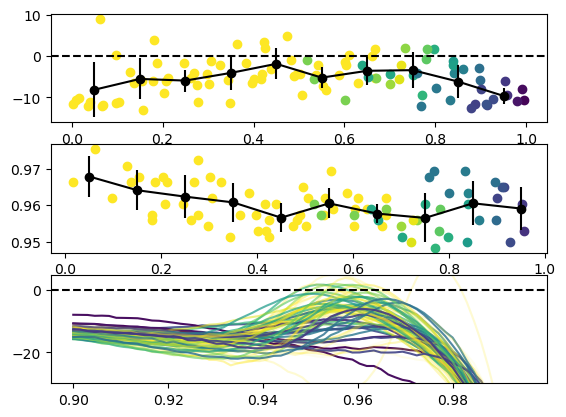

In [146]:
%matplotlib inline

fig, axs = plt.subplots(3, 1)

max_dq_dpsi = []
elm_phases = []
psimax_dq_dpsi = []

for i, time in enumerate(times):
    # Compute time in seconds
    t = time / 1000.0
    # Find index of next ELM
    ind = np.searchsorted(t_elms, t)

    # Check if we're in the whitelist; if so, proceed
    if ind-1 < len(elm_okay) and elm_okay[ind-1]:

        # Get time to next ELM
        to_next_elm = t - t_elms[ind]
        # Time since last elm
        since_last_elm = t - t_elms[ind-1]
        elm_phase = (t - t_elms[ind-1]) / (t_elms[ind] - t_elms[ind-1])

        dq_dpsi = np.gradient(qpsis[i]) / np.gradient(psi_n)

        max_dq_dpsi.append(np.max(dq_dpsi))
        elm_phases.append(elm_phase)

        psimax = psi_n[np.argmax(dq_dpsi)]
        if psimax < 0.94:
            psimax = np.nan

        psimax_dq_dpsi.append(psimax)

        color = mpl.cm.viridis(-to_next_elm / 0.05)

        axs[0].scatter(elm_phase, np.max(dq_dpsi), color=color)

        axs[1].scatter(elm_phase, psimax, color=color)

        axs[2].plot(psi_n, dq_dpsi, c=color, alpha=1.0 - np.clip(-to_next_elm / 0.1, 0.0, 1.0))
        
# Plot the average max dq/dpsi vs ELM phase in each bin of ELM phase
num_bins = 10
bins = np.linspace(0, 1, num_bins+1)
bin_indices = np.digitize(elm_phases, bins) - 1

def compute_bin_stats(values, bin_indices, num_bins):
    bin_means = np.zeros(num_bins)
    bin_std = np.zeros(num_bins)
    for b in range(num_bins):
        bin_means[b] = np.nanmean(np.array(values)[bin_indices == b])
        bin_std[b] = np.nanstd(np.array(values)[bin_indices == b])
    return bin_means, bin_std

mean_dq_dpsi_bins, std_dq_dpsi_bins = compute_bin_stats(max_dq_dpsi, bin_indices, num_bins)
mean_psin_bins, std_psin_bins = compute_bin_stats(psimax_dq_dpsi, bin_indices, num_bins)

axs[0].errorbar(bins[:-1] + 0.05, mean_dq_dpsi_bins, yerr=std_dq_dpsi_bins, c='k', marker='o')
axs[0].axhline(0, c='k', ls='--')

axs[1].errorbar(bins[:-1] + 0.05, mean_psin_bins, yerr=std_psin_bins, c='k', marker='o')

axs[2].axhline(0, c='k', ls='--')
axs[2].set_ylim(-30, 5)